# Fake News Detection with Sentence Embeddings

> **University:** Universidade do Vale do Rio dos Sinos (UNISINOS)<br />
> **Program:** Pós-graduação em Inteligência Artificial Aplicada<br />
> **Course:** Processamento de Linguagens Naturais<br />
> **Author:** Augusto Stahlschmidt<br />
> **Date:** November 15, 2025  

---

## 1. Introduction & Objectives

**Problem:**  
Misinformation spreads at unprecedented speed through social networks and digital media. Automatically detecting fake news based on textual content enables faster, more scalable monitoring, moderation, and user alerting.

**Task Type:**  
Binary Text Classification

**Business or Research Objective:**  
Build a pipeline that classifies Brazilian Portuguese news articles as real or fake, using semantic embeddings as text representation.

**Analytical Goal:**  
Evaluate whether sentence-level embeddings from a pre-trained Transformer model, combined with a lightweight linear classifier, can reliably distinguish fake from real news in the Fake.Br corpus.

**Primary Evaluation Metric:**  
Macro F1-score (balances precision and recall across both classes equally)

**Success Criteria:**  
Achieve macro F1-score above 0.80 on the held-out test set, with balanced performance across both classes.

## 2. Setup & Imports

In [1]:
import os
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sentence_transformers import SentenceTransformer

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

print("Environment ready")
print("Pandas version:", pd.__version__)

Environment ready
Pandas version: 3.0.1


## 3. Data Loading & Initial Inspection

**Dataset Source:**  
[GitHub — Fake.Br Corpus](https://github.com/roneysco/Fake.br-Corpus)

**Description:**  
A balanced Brazilian Portuguese fake news corpus containing 7,200 articles equally split between real and fake news. Real articles were collected from mainstream news outlets; fake articles were sourced from known misinformation websites. The preprocessed version applies lowercasing, stopword removal, and special character stripping.

**Features:**

| # | Feature | Type | Role | Description |
|---|---------|------|------|-------------|
| 1 | index | int | Identifier | Row index |
| 2 | label | str | Target | "fake" or "true" |
| 3 | preprocessed_news | str | Input | Preprocessed news article text |

**Unit of Analysis:**  
Individual news article

**Target Variable:**  
`label` — binary string, either "fake" or "true"

**Notes:**  
- The corpus is perfectly balanced (3,600 fake, 3,600 real), eliminating the need for class-balancing strategies.
- Text preprocessing was performed by the corpus authors, not within this notebook.

In [2]:
CORPUS_DIR = "Fake.br-Corpus"
DATA_PATH = os.path.join(CORPUS_DIR, "preprocessed", "pre-processed.csv")

if not os.path.exists(CORPUS_DIR):
    subprocess.run(
        ["git", "clone", "https://github.com/roneysco/Fake.br-Corpus.git"],
        check=True
    )

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum())

Cloning into 'Fake.br-Corpus'...


Shape: (7200, 3)


,index,label,preprocessed_news
0,0,fake,katia abreu diz vai colocar expulsao moldura n...
1,1,fake,ray peita bolsonaro conservador fake entrevist...
2,2,fake,reinaldo azevedo desmascarado policia federal ...
3,3,fake,relatorio assustador bndes mostra dinheiro pub...
4,4,fake,radialista americano fala sobre pt vendem ilus...



Data types:


index                int64
label                  str
preprocessed_news      str
dtype: object


Missing values:


index                0
label                0
preprocessed_news    0
dtype: int64

## 4. Exploratory Data Analysis (EDA)

Goals of this section:

- Verify class balance
- Examine text length distributions across classes
- Identify potential quality issues in the corpus

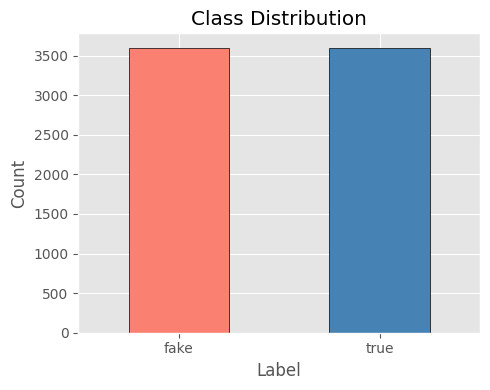

label
fake    3600
true    3600
Name: count, dtype: int64


In [3]:
# Class distribution
class_counts = df["label"].value_counts()

plt.figure(figsize=(5, 4))
class_counts.plot(kind="bar", color=["salmon", "steelblue"], edgecolor="black")
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(class_counts)

Word count statistics by class:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
fake,3600.0,107.940833,72.152004,5.0,67.75,92.0,130.0,1220.0
true,3600.0,624.935556,385.432837,13.0,364.00,523.0,806.0,4229.0


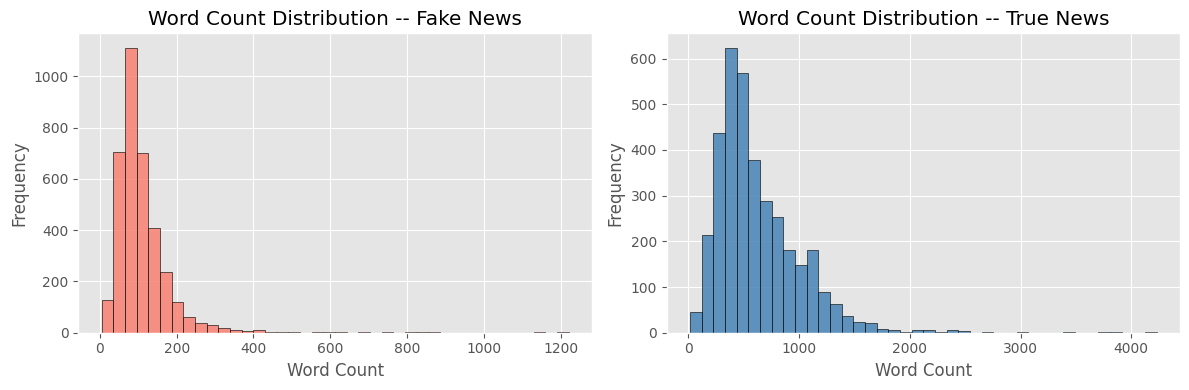

In [4]:
# Text length distribution by class
df["word_count"] = df["preprocessed_news"].str.split().str.len()

print("Word count statistics by class:")
display(df.groupby("label")["word_count"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (label, color) in zip(axes, [("fake", "salmon"), ("true", "steelblue")]):
    subset = df[df["label"] == label]["word_count"]
    ax.hist(subset, bins=40, color=color, edgecolor="black", alpha=0.85)
    ax.set_title(f"Word Count Distribution -- {label.capitalize()} News")
    ax.set_xlabel("Word Count")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

The corpus is perfectly balanced with 3,600 articles per class. Fake news articles tend to be shorter on average, though both distributions overlap considerably. This overlap means text length alone is not a reliable discriminative feature, reinforcing the need for richer semantic representations.

## 5. Preprocessing & Feature Engineering

Operations performed:

- Text is already preprocessed in the corpus (lowercased, stopwords removed, punctuation stripped)
- Sentence embeddings are generated using `all-MiniLM-L6-v2` via SentenceTransformer
- Embeddings are cached to disk to avoid recomputation on subsequent runs
- Train/test split with stratification to preserve class balance

**Representation rationale:**  
TF-IDF captures term frequency but ignores contextual meaning. Sentence embeddings from a pre-trained Transformer encode semantic relationships, enabling the model to detect subtle linguistic patterns characteristic of real versus fake news. Compared to fine-tuning a full Transformer end-to-end, this embedding-then-classify approach is computationally lighter, less prone to overfitting on a corpus of this size, and produces a strong, reproducible baseline.

No leakage risk applies here: the encoder is pre-trained and frozen, so no fitting occurs on training data.

In [5]:
EMBEDDINGS_FILE = "fakebr_embeddings.npz"
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

if not os.path.exists(EMBEDDINGS_FILE):
    print("Generating embeddings...")
    encoder = SentenceTransformer(MODEL_NAME)
    embeddings = encoder.encode(
        df["preprocessed_news"].tolist(),
        show_progress_bar=True,
        batch_size=64
    )
    np.savez(EMBEDDINGS_FILE, embeddings=embeddings, labels=df["label"].values)
    print("Embeddings saved to", EMBEDDINGS_FILE)
else:
    print("Loading cached embeddings from", EMBEDDINGS_FILE)

cache = np.load(EMBEDDINGS_FILE, allow_pickle=True)
embeddings = cache["embeddings"]
labels = cache["labels"]

print("Embeddings shape:", embeddings.shape)
print("Labels shape:", labels.shape)

Generating embeddings...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/113 [00:00<?, ?it/s]

Embeddings saved to fakebr_embeddings.npz
Embeddings shape: (7200, 384)
Labels shape: (7200,)


In [6]:
# Split embeddings, labels, and original texts together to preserve alignment
X_train, X_test, y_train, y_test, df_train, df_test = train_test_split(
    embeddings,
    labels,
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=labels
)
df_test = df_test.reset_index(drop=True)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (5760, 384)
Test set: (1440, 384)


## 6. Model Training

**Selected Model:**  
Logistic Regression. A linear classifier that maps the embedding dimensions to class probabilities. Since sentence embeddings already encode rich semantic structure in a dense vector space, a linear decision boundary is often sufficient and provides an interpretable, fast-to-train baseline.

**Key Hyperparameters:**

| Parameter | Value | Rationale |
|-----------|-------|----------|
| `max_iter` | 2000 | Ensures convergence on 384-dimensional embedding space |
| `random_state` | 42 | Reproducibility |

**Training Strategy:**  
Single stratified 80/20 train/test split. Cross-validation is deferred to future work, as the goal here is to establish a clean, reproducible baseline.

In [7]:
clf = LogisticRegression(max_iter=2000, random_state=SEED)
clf.fit(X_train, y_train)

print("Model training completed")

Model training completed


## 7. Model Evaluation

Evaluate performance on the held-out test set.

Includes:

- Classification report with precision, recall, and F1-score per class
- Confusion matrix visualization
- Qualitative error analysis on misclassified examples

In [8]:
y_pred = clf.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

        fake       0.85      0.77      0.81       720
        true       0.79      0.87      0.83       720

    accuracy                           0.82      1440
   macro avg       0.82      0.82      0.82      1440
weighted avg       0.82      0.82      0.82      1440



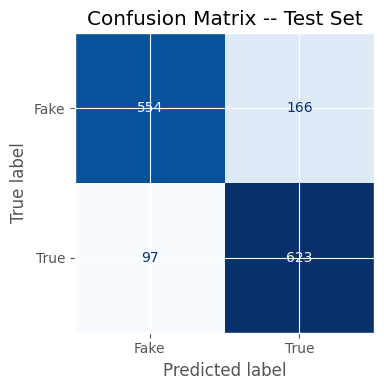

In [9]:
cm = confusion_matrix(y_test, y_pred, labels=["fake", "true"])

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake", "True"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix -- Test Set")
plt.tight_layout()
plt.show()

### 7.1 Error Analysis

The most critical failure mode is fake news classified as real, since it represents misinformation being passed as credible content. The analysis below examines representative misclassified examples to identify recurrent patterns.

In [14]:
fake_as_true_idx = np.where((y_test == "fake") & (y_pred == "true"))[0]
true_as_fake_idx = np.where((y_test == "true") & (y_pred == "fake"))[0]

print(f"Fake predicted as True (false negatives): {len(fake_as_true_idx)}")
print(f"True predicted as Fake (false positives): {len(true_as_fake_idx)}")

print("\nSample fake articles misclassified as true:")
for idx in fake_as_true_idx[:10]:
    print("\n-", df_test.iloc[idx]["preprocessed_news"], "...")

Fake predicted as True (false negatives): 166
True predicted as Fake (false positives): 97

Sample fake articles misclassified as true:

- coi quebra protocolo diz organizacao rio lastimavel john coates comite olimpico internacional coi desde anos disse rio olimpiada dificil ja realizada ate hoje coates ja havia alertado organizacao pior ja havia visto entrevista bbc confirmou novamente situacao lastimavel sido dificil jogos dificeis encontrado termos situacao economica politica disse rio escolhido pais quase potencia economica agora estao sofrendo disse coates transporte seguranca cor agua piscinas filas ingressos locais vazios situacao voluntarios problemas operacionais deixado membros coi cabelos pe proprio diretor comunicacao mario andrada pedido desculpas falhas quase diariamente hoje andrada admitiu poderia ter feito melhor aprendemos vamos fazer melhor futuros grandes eventos brasil disse andrada leia tambem ...

- padre surpreende cede igreja culto evangelico filhos deus recent

### 7.2 Misclassification Patterns

Analysis of the misclassified samples reveals some dominant failure modes:

**Political content saturated with institutional markers.**  
A significant share of false negatives cover politically charged topics and densely cite real individuals, parties, legal proceedings, and government bodies. This terminology closely mirrors the style of legitimate investigative journalism. The model associates these institutional signals with credibility, making partisan fabrications or misleading political framings nearly indistinguishable from factual reporting at the embedding level.

**Health misinformation structured as scientific communication.**  
Fake health articles that name real research institutions, cite researchers by credentials, and include disclaimers like "consult your doctor" produce embeddings that cluster tightly with genuine medical reporting. The model cannot distinguish between verified scientific findings and pseudoscientific claims when both are dressed in identical medical register.

**Real events used as cover for fabricated or distorted claims.**  
A recurring pattern involves fake articles that anchor a fabricated narrative within an accurate factual context: a real disaster, a real sporting event, or a real official statement. Because the surrounding context is legitimate, the overall embedding shifts toward the "true" region of the feature space, and the classifier fails to detect the fabricated core.

**International news mimicking wire agency style.**  
Fake articles covering foreign affairs often adopt the impersonal, fact-dense structure typical of international wire reporting, with plausible names, numbers, and geopolitical framing. Without access to external knowledge, the model cannot verify whether cited facts are accurate and treats the journalistic format as a proxy for credibility.

**Conspiratorial content wrapped in journalistic scaffolding.**  
Even articles with implausible or obviously fantastical claims can evade detection when they follow a journalistic structure: named sources, geographic specificity, hedged language, and references to social media reactions. The embedding encodes the structural form rather than the plausibility of the claims, causing the model to classify the article as credible.

## 8. Conclusions & Next Steps

**Key Findings**

- The corpus is perfectly balanced at 3,600 articles per class, making accuracy a meaningful complement to F1 and eliminating any need for class-weighting strategies.
- The most significant structural difference observed in the EDA is article length: fake news has a median of 92 words versus 523 for real news, a 5.7x gap. This length disparity likely contributes to embedding-level separability between classes and is a potential confounder of reported performance.
- No missing values were present. The corpus arrives already preprocessed with stopwords removed and punctuation stripped, reducing vocabulary noise but also eliminating punctuation patterns and function-word frequency signals that may carry class-discriminative information.
- Sentence embeddings from `all-MiniLM-L6-v2` produce 384-dimensional dense vectors, capturing semantic context that goes beyond surface token frequency. This makes them a stronger and more generalizable representation than TF-IDF for this task.

**Model Performance vs Success Criteria**

The success criterion was a macro F1-score above 0.80, with balanced performance across both classes.

The logistic regression classifier achieved a macro F1-score of 0.82, an overall accuracy of 0.82, and symmetric macro precision and recall of 0.82 across the 1,440-sample test set. The criterion was met.

| Class | Precision | Recall | F1-score | Support |
|-------|-----------|--------|----------|---------|
| fake  | 0.85      | 0.77   | 0.81     | 720     |
| true  | 0.79      | 0.87   | 0.83     | 720     |

The model produced 166 false negatives (fake articles classified as true) and 97 false positives (true articles classified as fake). False negatives outnumber false positives by a 1.7:1 ratio, indicating the model is systematically more conservative about flagging content as fake.

**Interpretation**

A recall of 0.77 for the fake class means approximately 1 in 4 fake articles would pass undetected in a deployed system. The higher precision of 0.85 indicates that when the model does flag an article as fake, it is correct most of the time, limiting unnecessary false alarms on real content.

The asymmetry between false negative and false positive rates reflects the stylistic sophistication of many misclassified fake articles. As identified in the error analysis, the most common failure mode involves fake content that borrows the vocabulary, institutional references, and structural conventions of legitimate journalism. The embedding space encodes these surface similarities, causing the classifier to score such articles as credible regardless of factual accuracy.

The substantial length gap between classes also suggests that a portion of the model's discriminative power may derive from length-related patterns in the embeddings rather than purely from semantic content.

**Limitations**

- Evaluation relies on a single 80/20 split with no cross-validation. The variance of the reported F1 estimate is unknown, and the metrics may shift noticeably under different random seeds.
- No hyperparameter search was performed on the logistic regression. The default regularization strength (C=1.0) may not be optimal for 384-dimensional input.
- The encoder (`all-MiniLM-L6-v2`) was trained primarily on English data. Brazilian Portuguese, particularly political and regional vocabulary, may be suboptimally represented.
- The corpus covers a specific political and temporal context in Brazil. Performance is expected to degrade on news from different periods or topics outside the Fake.Br distribution.
- Text preprocessing removed stopwords and punctuation before embedding, preventing the model from exploiting exclamation marks, capitalization patterns, or high-frequency function words that may differ between classes.

**Next Steps**

- Replace `all-MiniLM-L6-v2` with a Portuguese-specific encoder such as `neuralmind/bert-base-portuguese-cased` (BERTimbau) or `sentence-transformers/LaBSE` to improve semantic representation of Brazilian Portuguese text.
- Implement stratified k-fold cross-validation (k=5 or k=10) to obtain reliable confidence intervals for the reported macro F1.
- Fine-tune a full Transformer encoder on the task end-to-end, using the embedding-plus-logistic-regression result as a lower-bound baseline.
- Explore ensemble approaches combining sentence embeddings with TF-IDF vectors and structural features (word count, sentence count, presence of numeric tokens) to improve recall on the fake class.
- Tune the classification threshold of the logistic regression output probabilities to increase fake-class recall, with an explicit trade-off analysis against the resulting increase in false positives.